# Module 12 — Bayesian Statistics

**Statistics Deep Dive · Notebook 12 of 13**

Everything so far was *frequentist*: parameters are fixed unknowns, probability describes the long-run behaviour of procedures, and we were never allowed to say "the probability that the conversion rate exceeds 5 % is …". **Bayesian statistics** allows exactly that sentence. It treats unknown parameters as quantities we are *uncertain* about, describes that uncertainty with probability distributions, and uses Bayes' theorem (Module 2) to update it with data.

### 🎯 Learning goals
After this module you can …
1. explain **prior, likelihood, posterior** and the mechanics of Bayesian updating,
2. use the **conjugate** Beta–Binomial and Gamma–Poisson models and read priors as *pseudo-data*,
3. summarise posteriors with point estimates and **credible intervals** (equal-tailed and HDI), and distinguish them from confidence intervals,
4. run a **Bayesian A/B test**: $P(B>A)$, expected loss, decision rules,
5. make **posterior predictive** statements and explain **shrinkage**,
6. implement a **Metropolis MCMC** sampler from scratch and check its convergence.

### 🗺️ Contents
1. The Bayesian recipe · 2. Sequential updating · 3. Conjugate priors: Beta–Binomial · 4. Summarising a posterior · 5. Bayesian A/B testing · 6. Rates: Gamma–Poisson & prediction · 7. Shrinkage · 8. MCMC from scratch · 9. Bayesian vs. frequentist · 10. Exercises · 11. Takeaways

In [1]:
# --- Course setup (identical in every module) ---
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (9, 4.2), "figure.dpi": 90, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False})
C = sns.color_palette("deep")      # C[0] blue, C[1] orange, C[2] green, C[3] red, C[4] purple
rng = np.random.default_rng(42)    # seeded generator => reproducible results

# --- additional tools for this module ---
from scipy.special import gammaln
import statsmodels.formula.api as smf
from statsmodels.stats.proportion import proportion_confint, proportions_ztest

def hdi(samples, mass=.95):
    """Highest-density interval: the narrowest interval containing `mass` of the posterior draws."""
    s = np.sort(samples); m = int(np.ceil(mass * s.size)); widths = s[m - 1:] - s[:s.size - m + 1]; i = widths.argmin()
    return s[i], s[i + m - 1]

---
## 1. The Bayesian recipe

$$\underbrace{p(\theta\mid\text{data})}_{\text{posterior}}=\frac{\overbrace{p(\text{data}\mid\theta)}^{\text{likelihood}}\;\overbrace{p(\theta)}^{\text{prior}}}{\underbrace{p(\text{data})}_{\text{normalising constant}}}\qquad\Longrightarrow\qquad \text{posterior}\;\propto\;\text{likelihood}\times\text{prior}$$

* **Prior** $p(\theta)$ — what we know about the parameter *before* seeing the data (previous studies, domain knowledge, or deliberately vague).
* **Likelihood** $p(\text{data}\mid\theta)$ — the same function as in Module 5: how well does each parameter value explain the data?
* **Posterior** $p(\theta\mid\text{data})$ — what we know *after* seeing the data: a full probability distribution, from which every summary follows.

The denominator does not depend on $\theta$; it merely rescales the product so that it integrates to 1. With one parameter we can do the whole computation on a **grid**: evaluate prior × likelihood at many values of $\theta$ and normalise.

**Example.** A new landing page: 9 sign-ups among the first 50 visitors. Past pages converted around 10 %, rarely above 20 %.

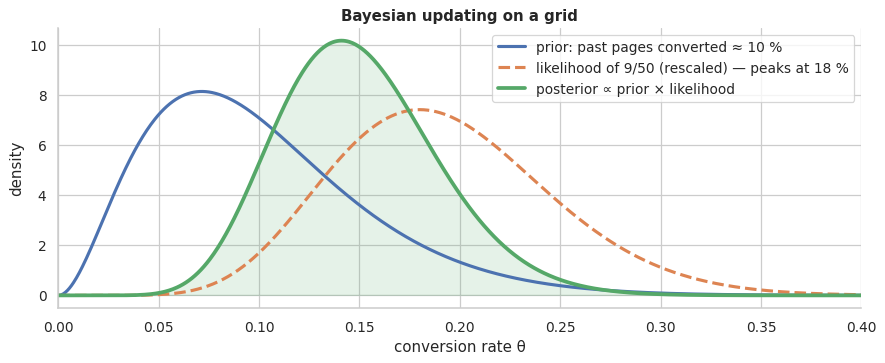

posterior mean = 0.150;   P(θ > 0.15 | data) = 0.47


In [2]:
theta = np.linspace(0, .5, 1001); dtheta = theta[1] - theta[0]
prior = stats.beta.pdf(theta, 3, 27)                                     # belief before the data: around 10 %
likelihood = stats.binom.pmf(9, 50, theta)                               # 9 sign-ups in 50 visitors
posterior = prior * likelihood; posterior /= posterior.sum() * dtheta     # multiply, then normalise so that the area is 1

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(theta, prior, color=C[0], lw=2.5, label="prior: past pages converted ≈ 10 %")
ax.plot(theta, likelihood / (likelihood.sum() * dtheta), color=C[1], lw=2.5, ls="--", label="likelihood of 9/50 (rescaled) — peaks at 18 %")
ax.plot(theta, posterior, color=C[2], lw=3, label="posterior ∝ prior × likelihood"); ax.fill_between(theta, posterior, color=C[2], alpha=.15)
ax.set(xlabel="conversion rate θ", ylabel="density", xlim=(0, .4), title="Bayesian updating on a grid"); ax.legend()
plt.tight_layout(); plt.show()
print(f"posterior mean = {(theta * posterior).sum() * dtheta:.3f};   P(θ > 0.15 | data) = {posterior[theta > .15].sum() * dtheta:.2f}")

**Reading the figure.** The posterior is a **compromise** between prior and data, and it is *narrower* than either — information has been added. The data alone say 18 %; the prior says such high values are unusual; the posterior settles around 15 %. And we can now answer the question management actually asks: *"How likely is it that this page converts better than 15 %?"*

---
## 2. Sequential updating — today's posterior is tomorrow's prior

Bayesian learning is naturally incremental: update after each observation, and the posterior becomes the prior for the next one. The end result is identical to processing all data at once. Below, a coin with unknown bias (true value 0.7) and a flat prior.

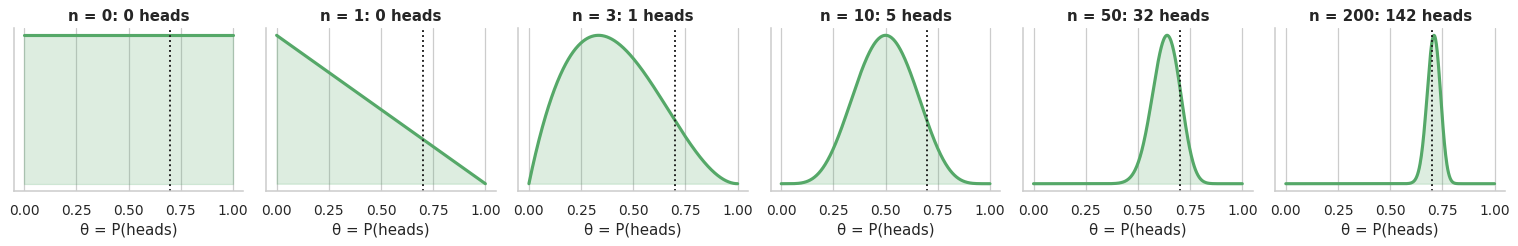

In [3]:
flips = (rng.random(200) < .7).astype(int); p = np.linspace(0, 1, 500)
fig, axes = plt.subplots(1, 6, figsize=(17, 2.9), sharex=True)
for ax, n in zip(axes, [0, 1, 3, 10, 50, 200]):
    heads = flips[:n].sum(); dens = stats.beta.pdf(p, 1 + heads, 1 + n - heads)
    ax.plot(p, dens, color=C[2], lw=2.5); ax.fill_between(p, dens, color=C[2], alpha=.2); ax.axvline(.7, color="k", ls=":")
    ax.set(yticks=[], title=f"n = {n}: {heads} heads", xlabel="θ = P(heads)")
plt.tight_layout(); plt.show()

With no data the belief is flat. A single head already tilts it; with more data the posterior **concentrates around the truth** and its width shrinks like $1/\sqrt n$ — the same rate as a frequentist standard error.

---
## 3. Conjugate priors — the Beta–Binomial model

For some prior–likelihood pairs the posterior has the *same form* as the prior — the prior is **conjugate**, and updating reduces to arithmetic. For a proportion:

$$\theta\sim\text{Beta}(a,b),\quad k\mid\theta\sim\text{Binomial}(n,\theta)\qquad\Longrightarrow\qquad \theta\mid k\sim\text{Beta}(a+k,\;b+n-k)$$

**Priors are pseudo-data.** Beta$(a,b)$ acts like having already seen $a$ successes and $b$ failures: prior mean $a/(a+b)$, prior "sample size" $a+b$. The posterior mean is a **weighted average** of prior mean and observed proportion,

$$E[\theta\mid k]=\frac{a+k}{a+b+n}=\underbrace{\frac{a+b}{a+b+n}}_{\text{weight of the prior}}\cdot\frac{a}{a+b}+\underbrace{\frac{n}{a+b+n}}_{\text{weight of the data}}\cdot\frac{k}{n}.$$

> 🤔 **Predict first:** three analysts hold very different priors. After 10 observations, do they agree? After 1,000?

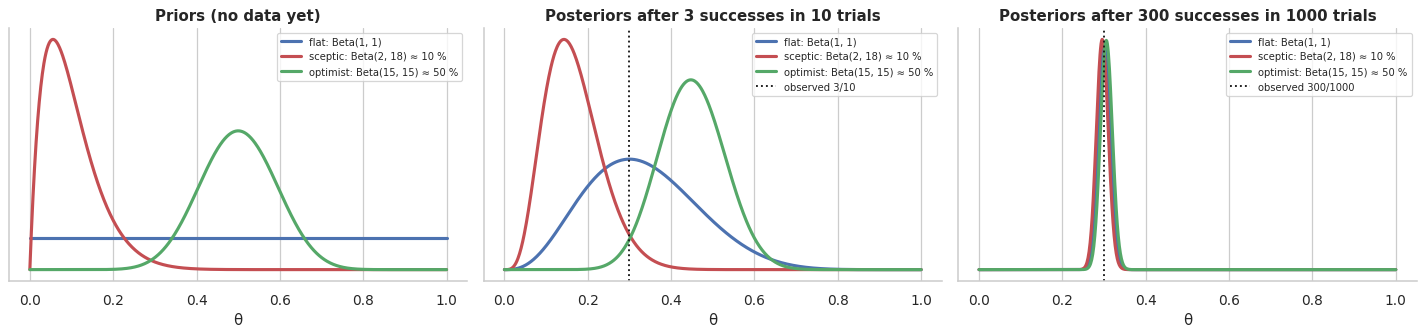

In [4]:
priors = {"flat: Beta(1, 1)": (1, 1), "sceptic: Beta(2, 18) ≈ 10 %": (2, 18), "optimist: Beta(15, 15) ≈ 50 %": (15, 15)}
p = np.linspace(0, 1, 800); fig, axes = plt.subplots(1, 3, figsize=(16, 3.9), sharex=True)
for ax, (k, n) in zip(axes, [(0, 0), (3, 10), (300, 1000)]):
    for (name, (a, b)), col in zip(priors.items(), [C[0], C[3], C[2]]):
        ax.plot(p, stats.beta.pdf(p, a + k, b + n - k), color=col, lw=2.5, label=name)
    if n: ax.axvline(k / n, color="k", ls=":", label=f"observed {k}/{n}")
    ax.set(yticks=[], xlabel="θ", title="Priors (no data yet)" if n == 0 else f"Posteriors after {k} successes in {n} trials"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Reading the figure.** With little data the prior matters — that is a feature when the prior encodes real knowledge, and a risk when it encodes wishful thinking. With lots of data **the likelihood dominates and all reasonable priors lead to the same posterior**. A good analysis reports how sensitive its conclusions are to the prior.

| Data model | Conjugate prior | Posterior | Typical use |
|---|---|---|---|
| Binomial ($k$ of $n$) | Beta$(a,b)$ | Beta$(a+k,\,b+n-k)$ | conversion, defect, response rates |
| Poisson (counts $y_1..y_n$) | Gamma$(\alpha,\beta)$ | Gamma$(\alpha+\sum y_i,\,\beta+n)$ | incident, arrival, claim rates |
| Normal mean (known $\sigma$) | Normal$(\mu_0,\tau^2)$ | Normal (precision-weighted average) | measurements, shrinkage |

---
## 4. Summarising a posterior

The posterior *is* the result. For reporting we condense it:

* **Point estimates:** posterior **mean** (minimises squared error), **median**, or **mode** (MAP — equals the MLE under a flat prior).
* **Credible interval:** a range that contains the parameter with, say, 95 % posterior probability. Two flavours: **equal-tailed** (2.5 % cut off on each side) and **highest-density interval, HDI** (the *narrowest* such interval; every point inside is more plausible than every point outside). They coincide for symmetric posteriors and differ for skewed ones.
* **Any probability statement** you like: $P(\theta>0.05)$, $P(\theta_B>\theta_A)$, …

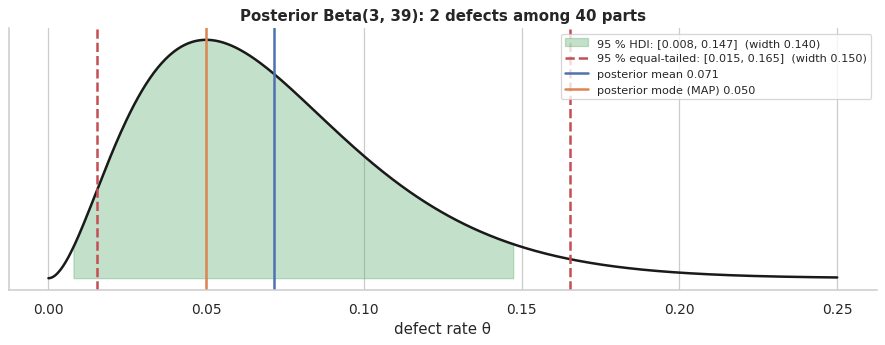

In [5]:
a, b = 1 + 2, 1 + 38                                                     # flat prior, 2 defects in 40 inspected parts
draws = stats.beta.rvs(a, b, size=200_000, random_state=rng); x = np.linspace(0, .25, 600); pdf = stats.beta.pdf(x, a, b)
eq = stats.beta.ppf([.025, .975], a, b); hd = hdi(draws)
fig, ax = plt.subplots(figsize=(10, 4)); ax.plot(x, pdf, color="k", lw=2)
ax.fill_between(x, pdf, where=(x >= hd[0]) & (x <= hd[1]), color=C[2], alpha=.35, label=f"95 % HDI: [{hd[0]:.3f}, {hd[1]:.3f}]  (width {hd[1] - hd[0]:.3f})")
for v in eq: ax.axvline(v, color=C[3], ls="--", lw=2)
ax.plot([], [], color=C[3], ls="--", lw=2, label=f"95 % equal-tailed: [{eq[0]:.3f}, {eq[1]:.3f}]  (width {eq[1] - eq[0]:.3f})")
ax.axvline(a / (a + b), color=C[0], lw=2, label=f"posterior mean {a / (a + b):.3f}"); ax.axvline((a - 1) / (a + b - 2), color=C[1], lw=2, label=f"posterior mode (MAP) {(a - 1) / (a + b - 2):.3f}")
ax.set(xlabel="defect rate θ", yticks=[], title="Posterior Beta(3, 39): 2 defects among 40 parts"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

### Credible interval vs. confidence interval

| | 95 % confidence interval (Module 5) | 95 % credible interval |
|---|---|---|
| What is random? | the interval (the parameter is fixed) | the parameter (the data are fixed) |
| Legitimate sentence | "95 % of intervals built this way cover the true value." | "Given model, prior and data, the parameter lies in this interval with probability 95 %." |
| Needs a prior? | no | yes |
| In practice | with weak priors and decent sample sizes the two are often numerically almost identical — but only the credible interval licenses the sentence most people *want* to say. |

---
## 5. Bayesian A/B testing

With a posterior for each variant, comparisons become direct. Draw many samples from both posteriors and **count**:

* $P(\theta_B>\theta_A\mid\text{data})$ — the probability that B is really better,
* the posterior distribution of the **lift** $\theta_B/\theta_A-1$ with a credible interval,
* the **expected loss** of shipping B: $E[\max(\theta_A-\theta_B,\,0)]$ — how much conversion do we give up *on average* if B is in fact worse? Ship B when this falls below a tolerance you can live with.

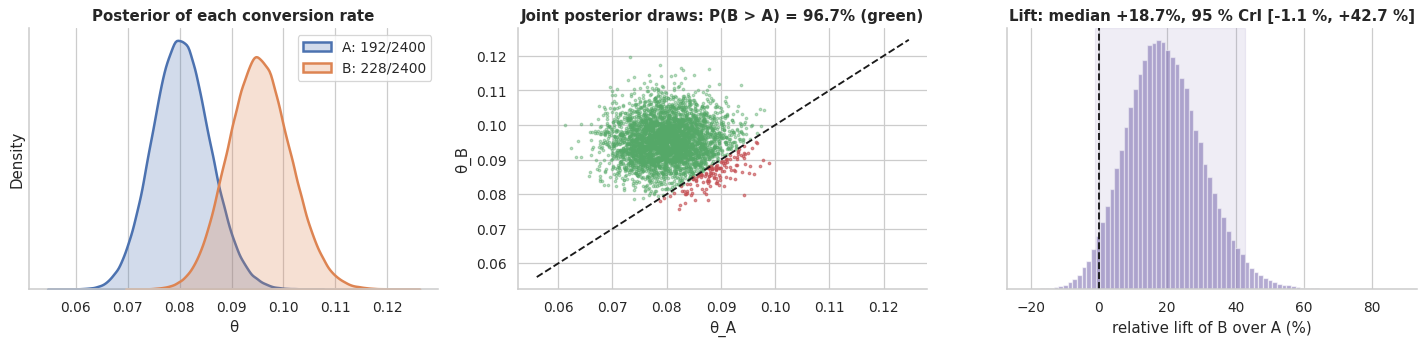

expected loss if we ship B: 0.0106 pp   |   if we keep A: 1.5120 pp


In [6]:
(nA, kA), (nB, kB) = (2400, 192), (2400, 228)                            # visitors, conversions
postA = stats.beta.rvs(1 + kA, 1 + nA - kA, size=200_000, random_state=rng); postB = stats.beta.rvs(1 + kB, 1 + nB - kB, size=200_000, random_state=rng)
lift = postB / postA - 1; p_better = (postB > postA).mean(); loss_B = np.maximum(postA - postB, 0).mean(); loss_A = np.maximum(postB - postA, 0).mean()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for d, col, lab in [(postA, C[0], f"A: {kA}/{nA}"), (postB, C[1], f"B: {kB}/{nB}")]: sns.kdeplot(d, ax=axes[0], color=col, fill=True, lw=2, label=lab)
axes[0].set(title="Posterior of each conversion rate", xlabel="θ", yticks=[]); axes[0].legend()
i = rng.choice(postA.size, 4000, replace=False); better = postB[i] > postA[i]
axes[1].scatter(postA[i][better], postB[i][better], s=4, color=C[2], alpha=.4); axes[1].scatter(postA[i][~better], postB[i][~better], s=4, color=C[3], alpha=.6)
lim = [postA.min(), postB.max()]; axes[1].plot(lim, lim, "k--"); axes[1].set(xlabel="θ_A", ylabel="θ_B", title=f"Joint posterior draws: P(B > A) = {p_better:.1%} (green)")
axes[2].hist(lift * 100, bins=80, color=C[4], alpha=.6); lo, hi = np.quantile(lift, [.025, .975]) * 100; axes[2].axvspan(lo, hi, color=C[4], alpha=.12); axes[2].axvline(0, color="k", ls="--")
axes[2].set(xlabel="relative lift of B over A (%)", yticks=[], title=f"Lift: median {np.median(lift):+.1%}, 95 % CrI [{lo:+.1f} %, {hi:+.1f} %]")
plt.tight_layout(); plt.show()
print(f"expected loss if we ship B: {loss_B * 100:.4f} pp   |   if we keep A: {loss_A * 100:.4f} pp")

**Reading the figure.** "B is better with 96 % probability, most likely by about +19 %, and if we are wrong we lose next to nothing" is a statement a product manager can act on. Compare the frequentist summary of the same data ($p\approx0.07$, "not significant"). The two analyses do not contradict each other — they answer different questions — but the Bayesian answer speaks the language of decisions.

> ⚠️ Bayesian A/B testing is **not immune to peeking** (Module 8) if you stop the moment $P(B>A)$ crosses a threshold; decision rules based on *expected loss* are more robust, and a minimum run time is still good practice.

---
## 6. Rates: the Gamma–Poisson model and posterior prediction

For counts per unit time with unknown rate $\lambda$: prior Gamma$(\alpha,\beta)$ ("$\alpha$ events seen in $\beta$ time units"), data $y_1,\dots,y_n\sim$ Poisson$(\lambda)$, posterior Gamma$(\alpha+\sum y_i,\ \beta+n)$.

**Posterior predictive distribution.** For forecasting we need the distribution of a **future observation**, averaging over our uncertainty about $\lambda$:

$$p(\tilde y\mid\text{data})=\int p(\tilde y\mid\lambda)\,p(\lambda\mid\text{data})\,d\lambda .$$

It is **wider** than the "plug-in" Poisson$(\hat\lambda)$, which pretends that $\lambda$ is known — the Bayesian counterpart of the prediction interval (Module 5). For the Gamma–Poisson pair the predictive distribution is negative binomial; in general we simulate: draw $\lambda$ from the posterior, then $\tilde y$ from Poisson$(\lambda)$.

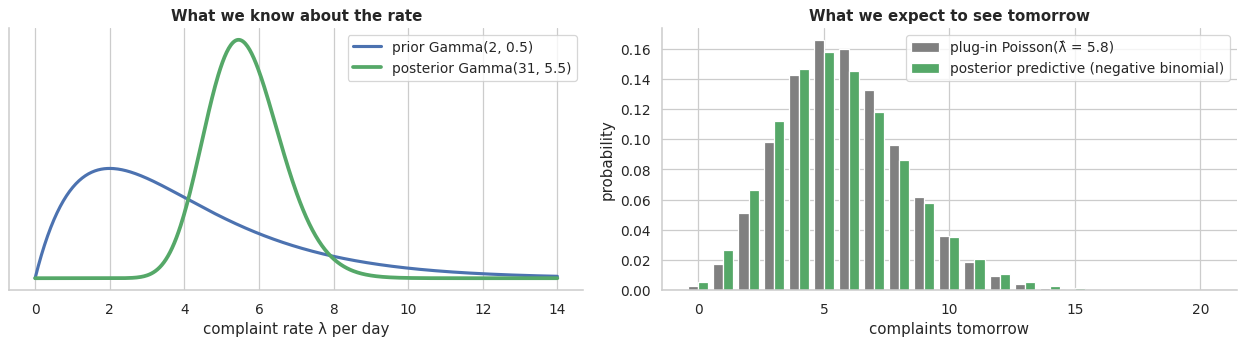

P(10 or more complaints tomorrow):  plug-in 0.071   vs.   posterior predictive 0.077


In [7]:
complaints = np.array([4, 7, 3, 6, 9]); alpha0, beta0 = 2, .5                 # 5 days of data; vague prior: mean 4 per day, worth half a day of data
alpha1, beta1 = alpha0 + complaints.sum(), beta0 + complaints.size
lam = np.linspace(0, 14, 500); k = np.arange(0, 21)
pred = stats.nbinom.pmf(k, alpha1, beta1 / (beta1 + 1))                     # exact posterior predictive
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4))
a1.plot(lam, stats.gamma.pdf(lam, alpha0, scale=1 / beta0), color=C[0], lw=2.5, label="prior Gamma(2, 0.5)"); a1.plot(lam, stats.gamma.pdf(lam, alpha1, scale=1 / beta1), color=C[2], lw=3, label=f"posterior Gamma({alpha1}, {beta1})")
a1.set(xlabel="complaint rate λ per day", yticks=[], title="What we know about the rate"); a1.legend()
a2.bar(k - .2, stats.poisson.pmf(k, complaints.mean()), width=.4, color="grey", label=f"plug-in Poisson(λ̂ = {complaints.mean():.1f})"); a2.bar(k + .2, pred, width=.4, color=C[2], label="posterior predictive (negative binomial)")
a2.set(xlabel="complaints tomorrow", ylabel="probability", title="What we expect to see tomorrow"); a2.legend()
plt.tight_layout(); plt.show()
print(f"P(10 or more complaints tomorrow):  plug-in {stats.poisson.sf(9, complaints.mean()):.3f}   vs.   posterior predictive {stats.nbinom.sf(9, alpha1, beta1 / (beta1 + 1)):.3f}")

---
## 7. Shrinkage — borrowing strength

Look again at the posterior-mean formula of section 3: the estimate is pulled from the raw proportion **towards the prior mean**, and the pull is strong when $n$ is small and negligible when $n$ is large. This **shrinkage** is the Bayesian answer to a very practical problem: *ranking units with very different sample sizes* (sellers, hospitals, schools, players). Raw rates put tiny-sample units at the top **and** the bottom of every ranking — purely by chance.

If the prior is itself estimated from the ensemble of all units, the method is called **empirical Bayes**; if it is given its own prior and estimated jointly, it is a **hierarchical model**. Simulation: 60 sellers whose true positive-review rates come from Beta(45, 5).

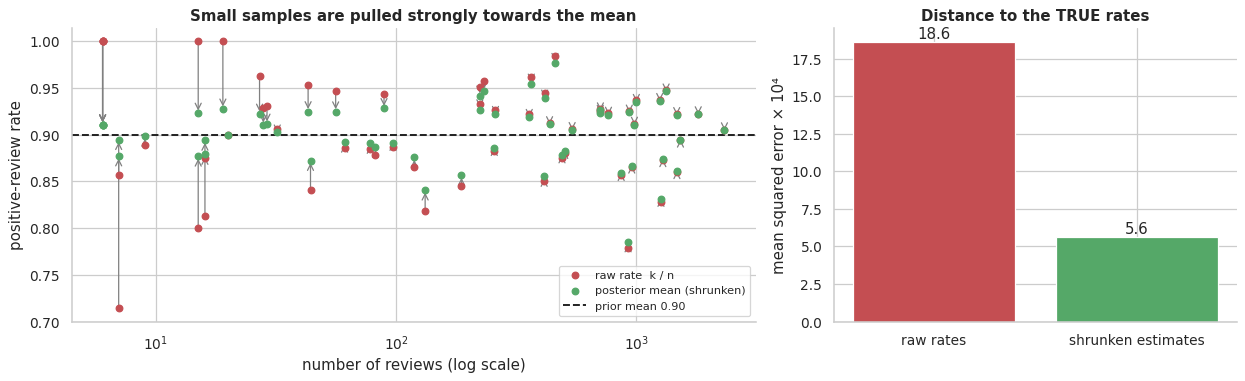

In [8]:
n_sellers = 60; true_rate = rng.beta(45, 5, n_sellers); n_rev = np.round(np.exp(rng.uniform(np.log(5), np.log(3000), n_sellers))).astype(int)
pos = rng.binomial(n_rev, true_rate); raw = pos / n_rev
a0, b0 = 45, 5                                                             # prior (here known; in practice estimated from many established sellers)
shrunk = (a0 + pos) / (a0 + b0 + n_rev)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4.4), gridspec_kw={"width_ratios": [1.7, 1]})
for x_, r, s_ in zip(n_rev, raw, shrunk): a1.annotate("", xy=(x_, s_), xytext=(x_, r), arrowprops=dict(arrowstyle="->", color="grey", lw=1))
a1.scatter(n_rev, raw, color=C[3], s=28, label="raw rate  k / n", zorder=3); a1.scatter(n_rev, shrunk, color=C[2], s=28, label="posterior mean (shrunken)", zorder=3)
a1.axhline(a0 / (a0 + b0), color="k", ls="--", label="prior mean 0.90"); a1.set(xscale="log", xlabel="number of reviews (log scale)", ylabel="positive-review rate", title="Small samples are pulled strongly towards the mean"); a1.legend(loc="lower right", fontsize=9)
err = pd.Series({"raw rates": np.mean((raw - true_rate) ** 2), "shrunken estimates": np.mean((shrunk - true_rate) ** 2)}) * 1e4
bars = a2.bar(err.index, err.values, color=[C[3], C[2]]); a2.bar_label(bars, fmt="%.1f"); a2.set(ylabel="mean squared error × 10⁴", title="Distance to the TRUE rates")
plt.tight_layout(); plt.show()

**Reading the figure.** Sellers with a handful of reviews move a lot, sellers with thousands barely at all. The shrunken estimates are *biased* towards the mean — and nevertheless much **closer to the truth on average** (bias–variance trade-off, Module 5; ridge regression in Module 10 is the same idea applied to regression coefficients).

---
## 8. When conjugacy ends — MCMC from scratch

Realistic models (several parameters, non-conjugate priors, regressions, hierarchies) have posteriors without a closed form, and grids explode in more than a few dimensions. **Markov chain Monte Carlo (MCMC)** sidesteps the problem: it produces a *sequence of draws* whose distribution converges to the posterior, using only the ability to evaluate **prior × likelihood up to a constant**.

**The Metropolis algorithm** (random-walk version):
1. Start somewhere. 2. **Propose** a random step from the current position. 3. If the proposal has a higher posterior density, **accept** it; if lower, accept it with probability *posterior(proposal) / posterior(current)*; otherwise stay (and record the current value again). 4. Repeat.

The chain spends time in each region in proportion to its posterior probability. The unknown normalising constant cancels in the ratio — that is the whole trick.

**Example.** Repair durations (hours) modelled as Gamma(shape $k$, scale $s$) — no conjugate prior exists. We sample $(\log k,\log s)$ with weak N(0, 3²) priors, and validate against a brute-force grid, which is still feasible with two parameters.

In [9]:
def metropolis(log_post, start, step, n_iter, rng):
    """Random-walk Metropolis sampler. Returns the chain (n_iter × dim) and the acceptance rate."""
    chain = np.empty((n_iter, len(start))); current = np.asarray(start, float); lp = log_post(current); accepted = 0
    for i in range(n_iter):
        proposal = current + rng.normal(0, step, size=current.size)             # 1. propose a random step
        lp_new = log_post(proposal)
        if np.log(rng.random()) < lp_new - lp:                                  # 2. accept with probability min(1, posterior ratio)
            current, lp = proposal, lp_new; accepted += 1
        chain[i] = current                                                      # 3. record the position (the old one again if rejected)
    return chain, accepted / n_iter

repair = rng.gamma(shape=3, scale=2, size=40)                                   # observed repair times (hours)
n_obs, sum_log, sum_x = repair.size, np.log(repair).sum(), repair.sum()
def log_post(theta):                                                            # theta = (log k, log s); works for scalars and for grids
    k, s = np.exp(theta[0]), np.exp(theta[1])
    loglik = (k - 1) * sum_log - sum_x / s - n_obs * k * np.log(s) - n_obs * gammaln(k)
    return loglik - (theta[0] ** 2 + theta[1] ** 2) / (2 * 3 ** 2)              # + log of the N(0, 3²) priors (up to a constant)

chain, acc = metropolis(log_post, start=[-1.0, 2.5], step=.15, n_iter=30_000, rng=rng)
burn = 2000; post = chain[burn:]
print(f"acceptance rate = {acc:.0%};  posterior means: shape k = {np.exp(post[:, 0]).mean():.2f}, scale s = {np.exp(post[:, 1]).mean():.2f}  (truth: 3, 2)")

acceptance rate = 41%;  posterior means: shape k = 3.15, scale s = 1.90  (truth: 3, 2)


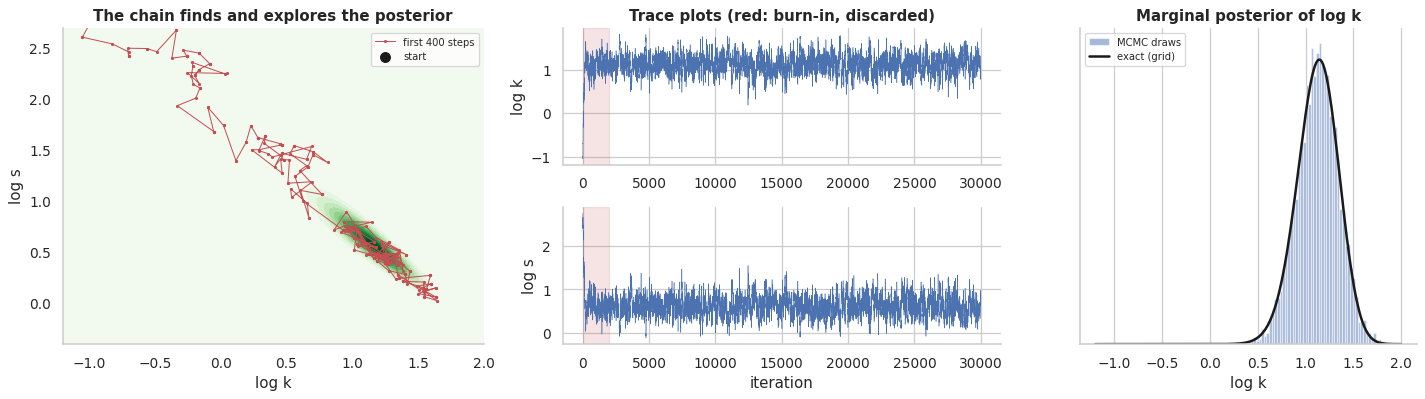

In [10]:
A, B = np.meshgrid(np.linspace(-1.2, 2, 260), np.linspace(-.4, 2.7, 260)); LP = log_post([A, B]); dens = np.exp(LP - LP.max())
fig = plt.figure(figsize=(16, 4.6)); gs = fig.add_gridspec(2, 3, width_ratios=[1.25, 1.3, 1])
ax = fig.add_subplot(gs[:, 0]); ax.contourf(A, B, dens, levels=12, cmap="Greens"); ax.plot(chain[:400, 0], chain[:400, 1], color=C[3], lw=.8, marker=".", ms=3, label="first 400 steps"); ax.scatter(*chain[0], color="k", s=60, zorder=3, label="start")
ax.set(xlabel="log k", ylabel="log s", xlim=(-1.2, 2), ylim=(-.4, 2.7), title="The chain finds and explores the posterior"); ax.legend(fontsize=8)
for r, (name, j) in enumerate([("log k", 0), ("log s", 1)]):
    axt = fig.add_subplot(gs[r, 1]); axt.plot(chain[:, j], color=C[0], lw=.4); axt.axvspan(0, burn, color=C[3], alpha=.15); axt.set_ylabel(name)
    axt.set_title("Trace plots (red: burn-in, discarded)" if r == 0 else ""); axt.set_xlabel("iteration" if r == 1 else "")
axm = fig.add_subplot(gs[:, 2]); axm.hist(post[:, 0], bins=60, density=True, color=C[0], alpha=.5, label="MCMC draws")
marg = dens.sum(axis=0); axm.plot(A[0], marg / (marg.sum() * (A[0, 1] - A[0, 0])), color="k", lw=2, label="exact (grid)"); axm.set(xlabel="log k", yticks=[], title="Marginal posterior of log k"); axm.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Reading the figure.** *Left:* from a poor starting point the chain walks uphill into the high-probability region and then wanders around it; the banana-shaped contours show that shape and scale are negatively correlated. *Middle:* healthy trace plots look like "hairy caterpillars" — stationary, no trends. The initial **burn-in** is discarded. *Right:* the histogram of draws matches the exact marginal — the sampler works.

### 8.1 Diagnosing a sampler — the step size matters

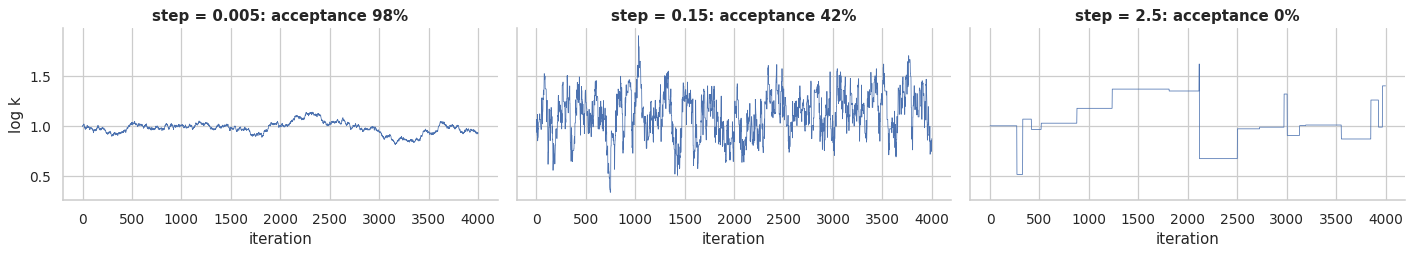

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 3), sharey=True)
for ax, step in zip(axes, [.005, .15, 2.5]):
    ch, ac = metropolis(log_post, [1.0, .8], step, 4000, rng)
    ax.plot(ch[:, 0], color=C[0], lw=.6); ax.set(title=f"step = {step}: acceptance {ac:.0%}", xlabel="iteration")
axes[0].set_ylabel("log k"); plt.tight_layout(); plt.show()

*Too small:* almost every proposal is accepted, but the chain crawls — highly autocorrelated draws, few *effective* samples. *Too large:* almost every proposal is rejected and the chain gets stuck. *About right:* acceptance around 20–50 %. Professional practice: run **several chains** from different starting points and check that they agree ($\hat R<1.01$), report the **effective sample size**, and look at trace plots. Modern software (Stan, PyMC, NumPyro) uses Hamiltonian Monte Carlo, which scales to thousands of parameters — but the logic is exactly what you just implemented.

---
## 9. Bayesian vs. frequentist — a fair comparison

| | Frequentist | Bayesian |
|---|---|---|
| Probability means | long-run frequency | degree of belief / state of knowledge |
| Parameters | fixed, unknown | uncertain → described by distributions |
| Result | estimate, CI, p-value | posterior distribution |
| Prior information | not used formally | explicit, must be justified |
| Typical sentence | "If $H_0$ were true, data this extreme would occur in 3 % of studies." | "Given the data, the effect is positive with probability 97 %." |
| Strengths | objective error guarantees, no prior needed, fast | direct answers, natural for decisions, prediction, small samples, hierarchical models |
| Weaknesses | awkward interpretation; nuisance with multiple looks and complex models | prior sensitivity with little data; computation; results depend on the model *and* the prior |

**Practical advice on priors.** (1) Use real knowledge when you have it (previous experiments, physical limits). (2) Otherwise prefer **weakly informative** priors that rule out the absurd (a conversion rate of 90 %, an odds ratio of 1,000) over "flat" priors, which are rarely as innocent as they look. (3) Always run a **sensitivity analysis**: if the conclusion changes under another reasonable prior, say so. With plenty of data, both schools give practically the same numbers — choose the one whose *statements* serve your audience.

---
## 10. Exercises — real-world use cases
Each exercise is self-contained. Run the data cell, then work in the empty cell below it.

### ✍️ Exercise 12.1 — *Beta–Binomial with an informative prior*: Early read-out of a product launch (Start-up analytics)

A start-up has launched a new subscription product. After two days: **3 purchases among 40 visitors**. The founders cheer about "7.5 % conversion". From a dozen earlier launches the team knows that conversion rates typically lie around 4 %, summarised as a Beta(4, 96) prior.

**Tasks**
1. Compute the posterior under the informative prior and under a flat Beta(1, 1) prior: mean, 95 % credible interval, and $P(\theta>5\,\%)$. Compare with the frequentist Wilson interval.
2. Plot prior and both posteriors.
3. Three weeks later the counts are **62 purchases among 1,000 visitors**. Repeat the analysis. What happened to the influence of the prior?
4. Which analysis would you have shown the investors after two days — and why?

In [12]:
prior_inf, prior_flat = (4, 96), (1, 1)
early, later = (3, 40), (62, 1000)                 # (purchases, visitors)

In [13]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/12_bayesian_statistics_solutions.ipynb`.

### ✍️ Exercise 12.2 — *Bayesian A/B test*: Which subject line goes to the full mailing list? (CRM)

Two e-mail subject lines were sent to 4,000 recipients each. Clicks: **A 184, B 221**. The winner will be sent to 500,000 customers. Marketing will switch to B if the *expected loss* of doing so is below **0.05 percentage points** of click rate.

**Tasks**
1. With Beta(1, 1) priors, draw 400,000 samples from each posterior. Compute $P(\theta_B>\theta_A)$.
2. Report the posterior median and 95 % credible interval of the relative lift.
3. Compute the expected loss of choosing B and of choosing A. What is the decision?
4. Run the frequentist two-proportion $z$-test on the same data. Put the two conclusions side by side: do they conflict?

In [14]:
n_A, k_A, n_B, k_B = 4000, 184, 4000, 221
g = np.random.default_rng(1202)

In [15]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/12_bayesian_statistics_solutions.ipynb`.

### ✍️ Exercise 12.3 — *Gamma–Poisson & posterior prediction*: Sizing the on-call team (IT operations)

A platform team took over a service twelve weeks ago. Weekly numbers of major incidents are given below. Similar services in the company average about 3 incidents per week, which the team encodes as a Gamma(6, 2) prior (mean 3, worth two weeks of data). The on-call rota can absorb **up to 5 incidents per week**.

**Tasks**
1. Compute the posterior of the incident rate $\lambda$ with a 95 % credible interval. Plot prior and posterior.
2. Compute the posterior predictive probability of **6 or more incidents next week**, and compare with the plug-in Poisson($\hat\lambda$) answer.
3. How many overload weeks should the team expect in the coming quarter (13 weeks)?
4. Check the predictive distribution by simulation (draw $\lambda$, then $y$).

In [16]:
incidents = np.array([2, 4, 1, 3, 5, 2, 2, 6, 3, 1, 4, 3])
alpha0, beta0 = 6, 2
g = np.random.default_rng(1203)

In [17]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/12_bayesian_statistics_solutions.ipynb`.

### ✍️ Exercise 12.4 — *Shrinkage*: Which seller deserves the "top-rated" badge? (Online marketplace)

A marketplace ranks sellers by their share of positive reviews. Established sellers' true rates are well described by a Beta(36, 4) distribution (mean 90 %).

**Tasks**
1. Rank the eight sellers by their raw positive rate. What is odd about the top of the list?
2. Compute each seller's posterior mean and the **5 % posterior quantile** (a "pessimistic score": we are 95 % sure the true rate is higher). Rank by both.
3. Seller E (3/3) or seller D (940/1000) — compute the posterior probability that E's true rate is higher than D's.
4. Which ranking rule would you implement, and why?

In [18]:
sellers = pd.DataFrame({"seller": list("ABCDEFGH"), "positive": [10, 48, 186, 940, 3, 27, 450, 88], "reviews": [10, 50, 200, 1000, 3, 30, 500, 100]}).set_index("seller")
a0, b0 = 36, 4
g = np.random.default_rng(1204)

In [19]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/12_bayesian_statistics_solutions.ipynb`.

### ✍️ Exercise 12.5 — *MCMC*: The Challenger O-ring data (Engineering risk, real data)

On 28 January 1986 the space shuttle *Challenger* was launched at **31 °F**, far colder than any previous launch, and was destroyed when an O-ring seal failed. Below are the 23 earlier flights with the launch temperature and whether O-ring damage was observed. Model: logistic regression $\text{logit}\,P(\text{damage})=\alpha+\beta\cdot(T-70)/10$ with weak N(0, 5²) priors.

**Tasks**
1. Code the log-posterior and sample it with the `metropolis` function (30,000 iterations; discard 3,000 as burn-in). Report the acceptance rate and inspect the trace plots.
2. What is the posterior probability that damage becomes *less* likely with rising temperature ($\beta<0$)?
3. Plot the data with 200 posterior curves and the posterior-mean curve from 30 to 85 °F.
4. Give the posterior median and 95 % credible interval of $P(\text{damage})$ at 31 °F. Cross-check $\hat\alpha,\hat\beta$ with a maximum-likelihood fit.
5. The engineers had no data below 53 °F. How should that affect the way you present the result?

In [20]:
temp = np.array([66, 70, 69, 68, 67, 72, 73, 70, 57, 63, 70, 78, 67, 53, 67, 75, 70, 81, 76, 79, 75, 76, 58])
damage = np.array([0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1])
g = np.random.default_rng(1205)

def metropolis(log_post, start, step, n_iter, rng):                     # the sampler from section 8, repeated so that the exercise is self-contained
    chain = np.empty((n_iter, len(start))); current = np.asarray(start, float); lp = log_post(current); accepted = 0
    for i in range(n_iter):
        proposal = current + rng.normal(0, step, size=current.size); lp_new = log_post(proposal)
        if np.log(rng.random()) < lp_new - lp: current, lp = proposal, lp_new; accepted += 1
        chain[i] = current
    return chain, accepted / n_iter

In [21]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/12_bayesian_statistics_solutions.ipynb`.

---
## 11. 🔑 Key takeaways

* **Posterior ∝ likelihood × prior.** The posterior is a full distribution: report means, **credible intervals** and any probability statement you need.
* **Conjugate models** (Beta–Binomial, Gamma–Poisson) turn updating into addition; a prior Beta$(a,b)$ is worth $a+b$ pseudo-observations.
* Little data → the prior matters (choose it carefully and check sensitivity). Lots of data → the likelihood dominates and Bayesian and frequentist answers converge.
* **Bayesian A/B tests** give decision-ready quantities: $P(B>A)$, the lift distribution, **expected loss**. They do not make peeking harmless.
* The **posterior predictive** distribution propagates parameter uncertainty into forecasts — it is always wider than the plug-in version.
* **Shrinkage** trades a little bias for a lot of variance and fixes small-sample rankings.
* **MCMC** needs only the un-normalised posterior. Always check convergence: trace plots, acceptance rate, several chains, effective sample size.

### Cheat sheet
| Task | Code |
|---|---|
| Beta–Binomial posterior | `post = stats.beta(a + k, b + n - k)`; `post.mean()`, `post.ppf([.025, .975])`, `post.sf(0.05)` |
| Gamma–Poisson posterior | `stats.gamma(alpha + y.sum(), scale=1 / (beta + len(y)))` |
| its posterior predictive | `stats.nbinom(alpha1, beta1 / (beta1 + 1))` |
| posterior draws | `stats.beta.rvs(a1, b1, size=100_000, random_state=rng)` |
| $P(B>A)$, expected loss | `(B > A).mean()`, `np.maximum(A - B, 0).mean()` |
| HDI from draws | `hdi(draws, .95)` (defined in the setup cell) |
| grid posterior | evaluate `prior * likelihood` on `np.linspace`, divide by `sum * step` |
| Metropolis | `metropolis(log_post, start, step, n_iter, rng)` (section 8) |
| full-scale Bayesian modelling | PyMC, Stan (`cmdstanpy`), NumPyro; diagnostics with ArviZ |

**Next:** Module 13 — data with a memory: time-series analysis and forecasting.